# Introduction:

*Stuff to add*

- Contents structure
- Explain what the project is about
- How we carried out the analysis
- What are the tools used



## Data Acquisition:

### Primary: Guardian API
We will collect articles from the Guardian API using commodity-related search terms (e.g. oil, natural gas, copper, wheat, OPEC, energy crisis) filtered by relevant sections (e.g. Business, Environment, World News). For each article, we may extract the publication date, headline, section, tags, word count, and body text. We plan to collect data spanning approximately 2014 - 2026 to capture multiple geopolitical cycles.

### Secondary: Commodity Price Data
To contextualise media coverage against market movements, we will source historical commodity price data from Yahoo Finance (via the yfinance Python library) or publicly available datasets. This will include daily/weekly prices for key commodities such as Brent Crude, natural gas, gold, copper, and wheat.

- Query the Guardian API with commodity-related keywords and display results across the full date range

- Download commodity price time series from Yahoo Finance using yfinance

- Store raw data in structured formats (JSON/CSV) for reproducibility



In [2]:
import json
import requests
import pandas as pd
import time
from datetime import date

with open('keys.json') as f:
    key = json.load(f)

API_KEY = key['guardian']['api_key']
BASE_URL = 'https://content.guardianapis.com'


date_ranges = [
    ("2020-01-01", "2020-06-30"),
    ("2020-07-01", "2020-12-31"),
    ("2021-01-01", "2021-06-30"),
    ("2021-07-01", "2021-12-31"),
    ("2022-01-01", "2022-06-30"),
    ("2022-07-01", "2022-12-31"),
    ("2023-01-01", "2023-06-30"),
    ("2023-07-01", "2023-12-31"),
    ("2024-01-01", "2024-06-30"),
    ("2024-07-01", "2024-12-31"),
    ("2025-01-01", "2025-12-31"),
]

all_results = []

for from_date, to_date in date_ranges:
    for page in range(1, 11):
        parameters = {
            "api-key": API_KEY,
            "q": "oil OR natural gas OR copper OR wheat OR OPEC OR energy crisis",
            "page-size": 50,
            "page": page,
            "show-fields": "bodyText",
            "from-date": from_date,
            "to-date": to_date,
            "order-by": "oldest"
        }

        response = requests.get(f"{BASE_URL}/search", params=parameters)
        response.raise_for_status()
        data = response.json()['response']


        results = data['results']
        total_pages = data['pages']

        for article in results:
            all_results.append({
                'date': article.get('webPublicationDate'),
                'section': article.get('sectionName'),
                'title': article.get('webTitle'),
                'body': article.get('fields', {}).get('bodyText', '')
            })

        if page >= total_pages:
            break

        time.sleep(0.1)

    print(f"  Total so far: {len(all_results)} articles")

df = pd.DataFrame(all_results)
df['date'] = pd.to_datetime(df['date'])
df = df.drop_duplicates(subset=['title'])
df.to_csv('data/guardian_commodities.csv', index=False)
print(f"\nFinal: {len(df)} articles saved")



  Total so far: 500 articles
  Total so far: 1000 articles
  Total so far: 1500 articles
  Total so far: 2000 articles
  Total so far: 2500 articles
  Total so far: 3000 articles
  Total so far: 3500 articles
  Total so far: 4000 articles
  Total so far: 4500 articles
  Total so far: 5000 articles
  Total so far: 5500 articles

Final: 5494 articles saved


In [3]:
import yfinance as yf


# Define commodity tickers
# Yahoo Finance uses these symbols for common commodities:
commodities = {
    "Gold":        "GC=F",   # Gold Futures
    "Silver":      "SI=F",   # Silver Futures
    "Crude Oil":   "CL=F",   # WTI Crude Oil Futures
    "Brent Oil":   "BZ=F",   # Brent Crude Futures
    "Natural Gas": "NG=F",   # Natural Gas Futures
    "Copper":      "HG=F",   # Copper Futures
    "Wheat":       "ZW=F",   # Wheat Futures
}

# Download historical data
data = yf.download(
    tickers=list(commodities.values()),
    start="2014-01-01",
    end="2026-03-31",
    interval="1d"       # 1d; daily
)

# Extract closing prices only
close_prices = data["Close"]
close_prices.columns = list(commodities.keys())

df_commodities_prices = pd.DataFrame(close_prices)


print(close_prices.head())


[*********************100%***********************]  7 of 7 completed

                  Gold     Silver    Crude Oil  Brent Oil  Natural Gas  \
Date                                                                     
2014-01-02  107.779999  95.440002  1225.000000     3.4315        4.321   
2014-01-03  106.889999  93.959999  1238.400024     3.4060        4.304   
2014-01-06  106.730003  93.430000  1237.800049     3.4120        4.306   
2014-01-07  107.349998  93.669998  1229.400024     3.4110        4.299   
2014-01-08  107.150002  92.330002  1225.300049     3.3935        4.216   

               Copper   Wheat  
Date                           
2014-01-02  20.098000  597.00  
2014-01-03  20.181999  605.75  
2014-01-06  20.077000  605.75  
2014-01-07  19.764999  602.50  
2014-01-08  19.518000  588.75  


# IDA

,date,section,title,body,word_count
0,2020-01-01 02:08:57+00:00,Australia news,What we know so far about the Australian bushf...,The bushfires have been spreading across New S...,242
1,2020-01-01 06:00:56+00:00,Food,Food in 2050: bacon grown on blades of grass a...,"In 2004, the Guardian correctly predicted that...",1707
2,2020-01-01 07:00:58+00:00,Environment,Shipping fuel regulation to cut sulphur levels...,Sulphur will be cut drastically from global sh...,929


,date,section,title,body,word_count
5497,2025-02-10 12:47:57+00:00,Business,BP shares jump after feared US hedge fund Elli...,Shares in BP jumped 7% on Monday after it emer...,583
5498,2025-02-10 14:00:35+00:00,Australia news,K’gari at risk of being ‘destroyed’ by overtou...,The K’gari’s world heritage advisory committee...,737
5499,2025-02-10 15:30:38+00:00,World news,Kosovo faces political uncertainty as ruling p...,"The governing party of the prime minister, Alb...",585


,date,section,title,body,word_count
801,2020-07-24 18:09:41+00:00,Politics,Boris Johnson admits government could have han...,Boris Johnson admitted the government could ha...,7798
3921,2023-07-26 00:00:03+00:00,Australia news,Are federal casual work law changes ‘good for ...,"It was “a good day for Australia’s casuals”, t...",955
1685,2021-07-19 17:30:04+00:00,Environment,‘A shocking failure’: Chevron criticised for m...,The energy giant Chevron has conceded its self...,783


Shape (rows, columns): (5494, 5)

Data types:
date          datetime64[ns, UTC]
section                    object
title                      object
body                       object
word_count                  int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
Index: 5494 entries, 0 to 5499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   date        5494 non-null   datetime64[ns, UTC]
 1   section     5494 non-null   object             
 2   title       5494 non-null   object             
 3   body        5494 non-null   object             
 4   word_count  5494 non-null   int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(3)
memory usage: 257.5+ KB

Missing values per column:
date          0
section       0
title         0
body          0
word_count    0
dtype: int64

Articles with empty body: 0

Any fully duplicate rows? False
Duplicate titles: 0
Duplicate body tex

,date,section,title,body,word_count
count,5494,5494,5494,5494,5494.000000
unique,NaN,47,5494,5487,NaN
top,NaN,Business,What we know so far about the Australian bushf...,,NaN
freq,NaN,798,1,8,NaN
mean,2022-07-20 08:20:34.438296576+00:00,NaN,NaN,NaN,1224.632326
min,2020-01-01 02:08:57+00:00,NaN,NaN,NaN,0.000000
25%,2021-02-05 17:21:19+00:00,NaN,NaN,NaN,571.000000
50%,2022-07-14 05:55:45.500000+00:00,NaN,NaN,NaN,782.000000
75%,2024-01-10 06:45:24.500000+00:00,NaN,NaN,NaN,1067.000000
max,2025-02-10 15:30:38+00:00,NaN,NaN,NaN,21320.000000



Article counts by section:
section
Business              798
World news            768
Environment           680
Australia news        618
Opinion               412
US news               309
Society               199
Politics              169
Money                 123
UK news               122
Life and style        117
Sport                 104
Global development    101
Food                   93
Books                  90
Name: count, dtype: int64

Earliest article: 2020-01-01 02:08:57+00:00
Latest article:   2025-02-10 15:30:38+00:00

Word count summary:
count     5494.000000
mean      1224.632326
std       1898.113812
min          0.000000
25%        571.000000
50%        782.000000
75%       1067.000000
max      21320.000000
Name: word_count, dtype: float64

Articles under 50 words (likely stubs): 9


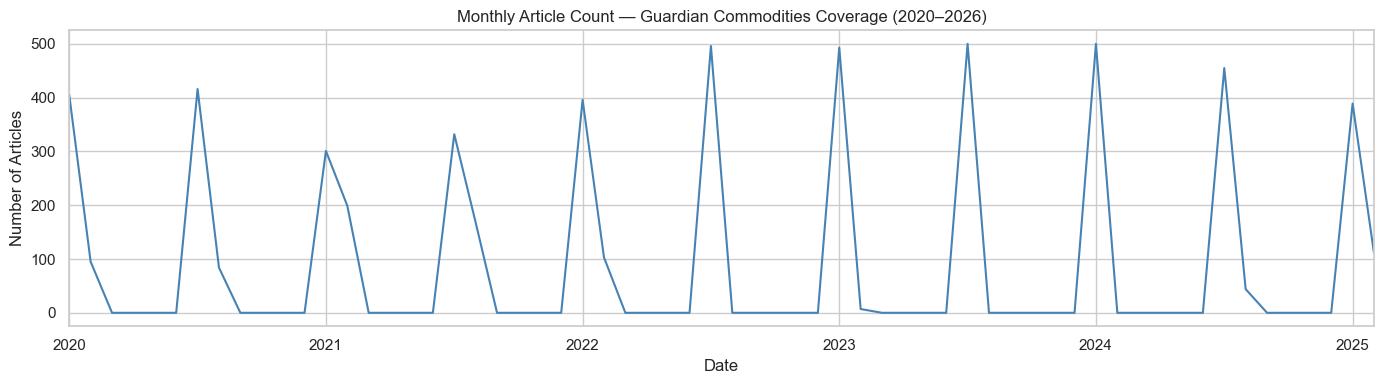

,Gold,Silver,Crude Oil,Brent Oil,Natural Gas,Copper,Wheat
Date,,,,,,,
2014-01-02,107.779999,95.440002,1225.000000,3.4315,4.321,20.098000,597.00
2014-01-03,106.889999,93.959999,1238.400024,3.4060,4.304,20.181999,605.75
2014-01-06,106.730003,93.430000,1237.800049,3.4120,4.306,20.077000,605.75


,Gold,Silver,Crude Oil,Brent Oil,Natural Gas,Copper,Wheat
Date,,,,,,,
2026-03-26,108.010002,94.480003,4375.5,5.4465,2.999,67.670998,605.0
2026-03-27,112.570000,99.639999,4492.0,5.4670,3.095,69.544998,605.0
2026-03-30,112.779999,102.879997,4526.0,5.4760,2.887,70.323997,607.0


,Gold,Silver,Crude Oil,Brent Oil,Natural Gas,Copper,Wheat
Date,,,,,,,
2021-01-08,55.990002,52.240002,1834.099976,3.6735,2.700,24.582001,638.75
2023-06-20,75.900002,70.500000,1935.500000,3.8785,2.492,23.193001,695.75
2024-09-16,72.750000,70.089996,2580.399902,4.2130,2.373,30.771000,578.50


Shape: (3079, 7)

Data types:
Gold           float64
Silver         float64
Crude Oil      float64
Brent Oil      float64
Natural Gas    float64
Copper         float64
Wheat          float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3079 entries, 2014-01-02 to 2026-03-30
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gold         3077 non-null   float64
 1   Silver       3078 non-null   float64
 2   Crude Oil    3077 non-null   float64
 3   Brent Oil    3078 non-null   float64
 4   Natural Gas  3079 non-null   float64
 5   Copper       3077 non-null   float64
 6   Wheat        3077 non-null   float64
dtypes: float64(7)
memory usage: 192.4 KB

Missing values per commodity:
Gold           2
Silver         1
Crude Oil      2
Brent Oil      1
Natural Gas    0
Copper         2
Wheat          2
dtype: int64

Any duplicate rows? False

Descriptive statistics — commodity prices:


,Gold,Silver,Crude Oil,Brent Oil,Natural Gas,Copper,Wheat
count,3077.000000,3078.000000,3077.000000,3078.000000,3079.000000,3077.000000,3077.000000
mean,69.459551,64.954584,1790.430547,3.400383,3.265461,22.876573,571.276162
std,19.607407,19.004720,779.513381,0.905147,1.329721,11.502114,136.742189
min,19.330000,-37.630001,1050.800049,1.939500,1.482000,11.735000,361.000000
25%,55.470001,50.752500,1266.099976,2.673500,2.539000,16.510000,490.000000
50%,67.830002,63.299999,1571.800049,3.131250,2.893000,19.497000,535.250000
75%,81.400002,76.740000,1932.000000,4.134875,3.654500,24.846001,615.500000
max,127.980003,123.699997,5318.399902,6.175500,9.680000,115.080002,1425.250000



Earliest date: 2014-01-02 00:00:00
Latest date:   2026-03-30 00:00:00

Zero or negative price counts:
  Silver: 1 rows


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#displays first 3, last 3, and 3 random rows of the dataframe to check the data looks like how it is expected to.
display(df.head(3))
display(df.tail(3))
display(df.sample(3))

#displays the shape of the dataframe
print("Shape of dataframe (rows, columns):", df.shape)

#summarises dataframe structure: row count, non-null counts, and data types per column
print()
df.info()

#check the number of missing values per column 
print("\nMissing values per column:")
print(df.isna().sum())

#
print("\nAny fully duplicate rows?", df.duplicated().any())
print("Duplicate titles:", df.duplicated(subset=['title']).sum())
print("Duplicate body text:", df.duplicated(subset=['body']).sum())

print("\nDescriptive statistics — Guardian articles:")
display(df.describe(include='all'))

print("\nArticle counts by section:")
print(df['section'].value_counts().head(15))

print(f"\nEarliest article: {df['date'].min()}")
print(f"Latest article:   {df['date'].max()}")

df['word_count'] = df['body'].str.split().str.len()
print("\nWord count summary:")
print(df['word_count'].describe())
print(f"\nArticles under 50 words (likely stubs): {(df['word_count'] < 50).sum()}")

monthly_counts = df.set_index('date').resample('ME').size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue')
ax.set_title('Monthly Article Count — Guardian Commodities Coverage (2020–2026)')
ax.set_ylabel('Number of Articles')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

display(df_commodities_prices.head(3))
display(df_commodities_prices.tail(3))
display(df_commodities_prices.sample(3))

print("Shape:", df_commodities_prices.shape)
print("\nData types:")
print(df_commodities_prices.dtypes)
print()
df_commodities_prices.info()

print("\nMissing values per commodity:")
print(df_commodities_prices.isna().sum())

print("\nAny duplicate rows?", df_commodities_prices.duplicated().any())

print("\nDescriptive statistics — commodity prices:")
display(df_commodities_prices.describe())

print(f"\nEarliest date: {df_commodities_prices.index.min()}")
print(f"Latest date:   {df_commodities_prices.index.max()}")

print("\nZero or negative price counts:")
for col in df_commodities_prices.columns:
    n = (df_commodities_prices[col] <= 0).sum()
    if n > 0:
        print(f"  {col}: {n} rows")


# Data wrangling

# EDA  

# Visualisation